In [2]:
import numpy as np
import pymc as pm
import pandas as pd
import scipy.stats as stats
import scipy.special as special
import matplotlib.pyplot as plt

Michelle is running for office and you're her campaign manager for the state of Minnesota. As such, you've conducted 30 different polls throughout the election season. Though Michelle's support has hovered around 45%, she polled at around 35% in the dreariest days and around 55% in the best days on the campaign trail.

How can you encode your knowledge of Michelle's support $\theta$ in a probability distribution? You want an distribution
- supported on $0\leq \theta\leq 1$,
- centered at $0.45$, 
- with most of its mass between $0.35$ and $0.45$.

A convenient family of distributions with support on $0\leq \theta \leq 1$ is the family $\operatorname{Beta}(a, b)$ of *beta distributions*. The beta family has two parameters $a > 0$ and $b > 0$ and density given by
$$
    p(\theta\mid a, b) = c\theta^{a - 1}(1 - \theta)^{b - 1}
$$
By choosing $a$ and $b$ appropriately, we can make a beta distribution centered at $0.45$ with most of its mass between $0.35$ and $0.45$. To see how this is done, we note two facts about $\operatorname{Beta}(a, b)$:
1. Its mean is $\mu=\dfrac{a}{a + b}$.
2. Its variance is $\sigma^2 = \dfrac{ab}{(a + b)^2(a + b + 1)}$.

To construct a beta distribution with a given mean $\mu$ and a given variance $\sigma^2$, we solve the above equations for $a$ and $b$. Doing so gives
$$
a = \mu\left(\frac{\mu(1 - \mu)}{\sigma^2} - 1\right),\qquad
b = (1 - \mu)\left(\frac{\mu(1 - \mu)}{\sigma^2} - 1\right).
$$

To construct a beta distribution centered at $0.45$ with most of its mass between $0.35$ and $0.45$, we take $\mu = 0.45$ and $\sigma = 0.05$, giving

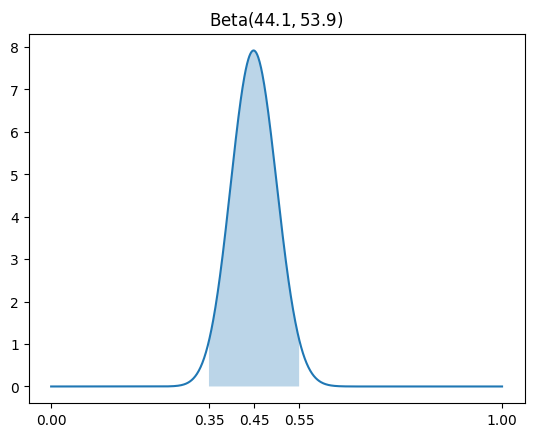

In [3]:
def a_and_b(mu, sigma):
    k = mu * (1 - mu) / sigma**2 - 1
    a = mu * k
    b = (1 - mu) * k
    return a, b


a, b = a_and_b(0.45, 0.05)
d = stats.beta(a, b)
assert np.isclose(0.45, d.mean())
assert np.isclose(0.05, d.std())
d.cdf(0.55) - d.cdf(0.35)

grid = np.linspace(0, 1, 1000)
plt.plot(grid, d.pdf(grid))

grid = np.linspace(0.35, 0.55, 1000)
plt.fill_between(grid, 0, d.pdf(grid), alpha=0.3)
plt.xticks([0, 0.35, 0.45, 0.55, 1])
plt.title(f"$\\operatorname{{Beta}}({a:.1f}, {b:.1f})$")
plt.show()

In a new poll of $n=50$ voters, $x=30$ indicate support for Michelle. What is the corresponding posterior distribution of $\theta$?

Modelling the poll as a binomial random variable with parameter $\theta$, we have
$$
p(x\mid\theta) \propto \theta^x(1 - \theta)^{n - x}.
$$

By Bayes' Theorem,
$$
\begin{aligned}
p(\theta\mid x) &\propto p(x\mid\theta)p(\theta)\\
&\propto \theta^x(1 - \theta)^{n - x}\theta^{a - 1}(1 - \theta)^{b - 1}\\
&= \theta^{a + x - 1}(1 - \theta)^{b + n - x - 1}
\end{aligned}
$$
Thus, $p(\theta\mid x)$ is proportional &mdash; hence, equal &mdash; to the density of the beta distribution with parameters
$$
a' = a + x,\qquad b' = b + n - x.
$$

Therefore, the posterior distribution of Michelle's support is $\operatorname{Beta}(74.1, 73.9)$.

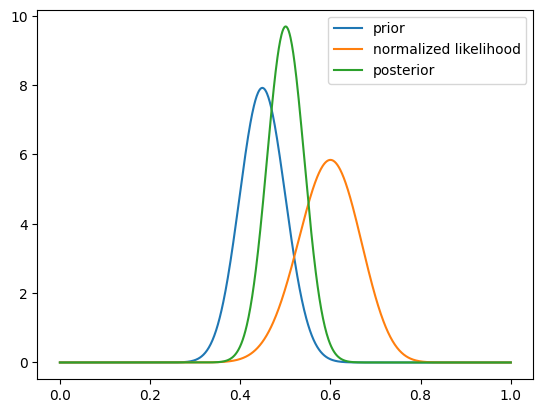

In [4]:
n = 50
x = 30
aa = a + x
bb = b + n - x
dd = stats.beta(aa, bb)
grid = np.linspace(0, 1, 1000)
prior = d.pdf(grid)
likelihood = stats.binom(n, grid).pmf(x)
normalized_likelihood = likelihood / np.trapezoid(likelihood, x=grid)
posterior = dd.pdf(grid)
plt.plot(grid, prior, label="prior")
plt.plot(grid, normalized_likelihood, label="normalized likelihood")
plt.plot(grid, posterior, label="posterior")
plt.legend()
plt.show()

Note the posterior strikes a compromise between the prior and the data.

The posterior mean is
$$
\mu'=\frac{a + x}{a + x + b + n - x} = \frac{a + x}{a + b + n}:
$$

Observe:
$$
\begin{aligned}
\frac{a + x}{a + b + n} &= \frac{a}{a + b + n} + \frac{x}{a + b + n}\\
&= \left(\frac{a + b}{a + b + n}\right)\frac{a}{a + b} + \left(\frac{n}{a + b + n}\right)\frac{x}{n}
\end{aligned}
$$
and
$$
\frac{a + b}{a + b + n} + \frac{n}{a + b + n} = 1.
$$

Thus, the posterior mean is a convex combination of the prior mean and the data estimate.

Moreover,
$$
\frac{a + b}{a + b + n}\to 0\qquad\text{and}\qquad \frac{n}{a + b + n}\to 1
$$
as $n\to\infty$. Thus, in the large data limit, the data estimate dominates and the prior loses relevance.

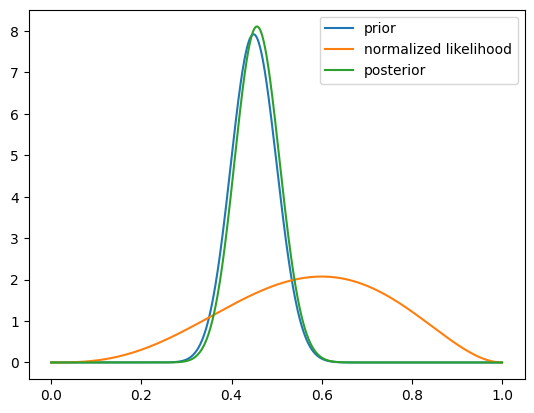

In [5]:
n = 5
x = 3
aa = a + x
bb = b + n - x
dd = stats.beta(aa, bb)
grid = np.linspace(0, 1, 1000)
prior = d.pdf(grid)
likelihood = stats.binom(n, grid).pmf(x)
normalized_likelihood = likelihood / np.trapezoid(likelihood, x=grid)
posterior = dd.pdf(grid)
plt.plot(grid, prior, label="prior")
plt.plot(grid, normalized_likelihood, label="normalized likelihood")
plt.plot(grid, posterior, label="posterior")
plt.legend()
plt.show()

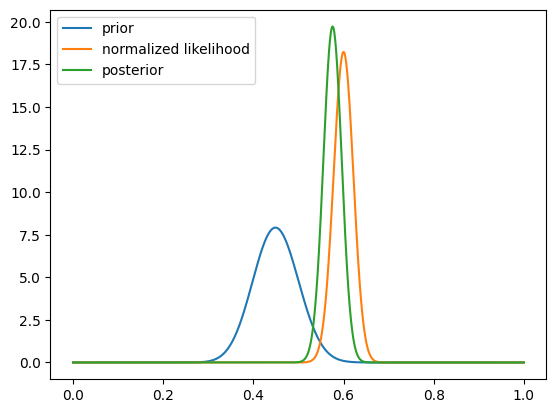

In [6]:
n = 500
x = 300
aa = a + x
bb = b + n - x
dd = stats.beta(aa, bb)
grid = np.linspace(0, 1, 1000)
prior = d.pdf(grid)
likelihood = stats.binom(n, grid).pmf(x)
normalized_likelihood = likelihood / np.trapezoid(likelihood, x=grid)
posterior = dd.pdf(grid)
plt.plot(grid, prior, label="prior")
plt.plot(grid, normalized_likelihood, label="normalized likelihood")
plt.plot(grid, posterior, label="posterior")
plt.legend()
plt.show()

You are going to take a random sample of voters in a city in order to estimate the proportion $\theta$ who support stopping the fluoridation of the municipal water supply. Before you analyze the data, you need a prior distribution for $\theta$. You decide that your prior mean is $0.4$, and your prior standard deviation is $0.1$. Out of the $n = 100$ city voters polled, $x = 21$ support the removal of fluoridation from the municipal water supply. Determine your posterior distribution. What is the posterior probability that support for the removal is less than $30\%$?

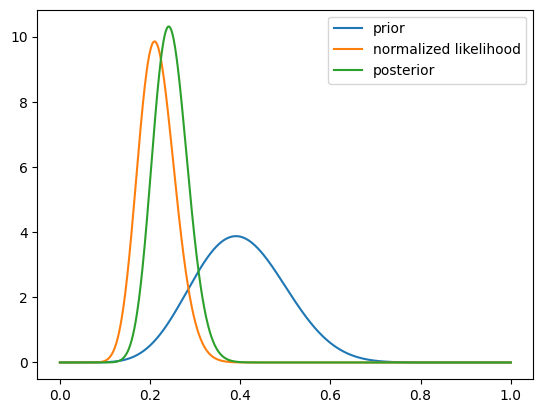

In [7]:
grid = np.linspace(0, 1, 1000)

mu = 0.4
sigma = 0.1
a, b = a_and_b(mu, sigma)
prior = stats.beta(a, b).pdf(grid)

n = 100
x = 21
likelihood = stats.binom(n, grid).pmf(x)
normalized_likelihood = likelihood / np.trapezoid(likelihood, x=grid)

aa = a + x
bb = b + n - x
posterior = stats.beta(aa, bb).pdf(grid)

plt.plot(grid, prior, label="prior")
plt.plot(grid, normalized_likelihood, label="normalized likelihood")
plt.plot(grid, posterior, label="posterior")
plt.legend()
plt.show()

In [8]:
stats.beta(aa, bb).cdf(0.3)

np.float64(0.9156363198946242)

The next day, another poll is performed with 35 out of 60 voters indicating support for Michelle. Update your posterior accordingly.

In [9]:
a, b = a_and_b(0.45, 0.05)
n = 50
x = 30
aa = a + x
bb = b + n - x
nn = 60
xx = 40
aaa = aa + xx
bbb = bb + nn - xx

In [10]:
aaa, bbb

(114.1, 93.9)

In [11]:
a + x + xx, b + n + nn - x - xx

(114.1, 93.9)

We've seen that a beta prior and a binomial likelihood give rise to a beta posterior. This is an example of *conjugacy*. A family $F$ of prior distributions is conjugate to family $G$ of likelihoods if the posterior for any prior from $F$ and any likelihood from $G$ belongs ot $F$. Thus, the family of beta distributions is conjugate to the family of binomial likelihoods. In such cases, there is typically a formula for the parameters of the posterior. This is extremely convenient, so we look for other examples of conjugacy.

### Gamma-Poisson conjugacy
The family of *Gamma distributions* has two parameters $r>0$ and $s>0$ and density determined by
$$
p(\lambda\mid r, s)\propto \lambda^{s - 1}e^{-r\lambda}.
$$

The family of *Poisson distributions* has one parameter $\lambda > 0$ and density 
$$
p(x\mid \lambda) = \frac{\lambda^xe^{-\lambda}}{x!}.
$$

The posterior for a gamma prior and a Poisson likelihood takes the form
$$
p(\lambda\mid x)\propto p(x\mid\lambda)p(\lambda)
\propto \frac{\lambda^xe^{-\lambda}}{x!}\lambda^{s - 1}e^{-r\lambda}
\propto \lambda^{s + x - 1}e^{-(r + 1)\lambda}
$$

$$
p(\lambda\mid y_1,\ldots,y_n) \propto \lambda^{x_1+\cdots+x_n}e^{-n\lambda}
$$

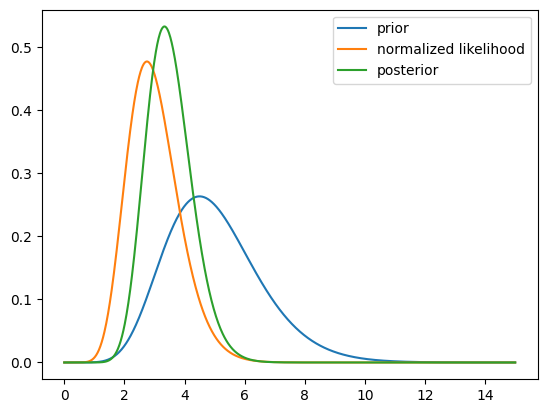

In [12]:
s = 10
r = 2
grid = np.linspace(0, 15, 1000)
d = stats.gamma(s, scale=1 / r)
plt.plot(grid, d.pdf(grid), label="prior")

y = np.array([6, 2, 2, 1])
likelihood = stats.poisson(grid).pmf(y.reshape(-1, 1)).prod(axis=0)
normalized_likelihood = likelihood / np.trapezoid(likelihood, x=grid)
plt.plot(grid, normalized_likelihood, label="normalized likelihood")

ss = s + y.sum()
rr = r + len(y)
dd = stats.gamma(ss, scale=1 / rr)
plt.plot(grid, dd.pdf(grid), label="posterior")

plt.legend()
plt.show()

Gamma distribution mean and variance:
$$
\mu = \frac{s}{r},\qquad \sigma^2 = \frac{s}{r^2}
$$

Solve for $s$ and $r$ in terms $\mu$ and $\sigma^2$:
$$
r = \frac{\mu}{\sigma^2},\qquad s = \frac{\mu^2}{\sigma^2}
$$

$$
s' = s + \sum_{i=1}^n y_i,\qquad r' = r + n
$$

$$
\mu' = \frac{s + n\bar{y}}{r + n} = \frac{s}{r + n} + \frac{n\bar{y}}{r + n}
= \left(\frac{r}{r + n}\right)\frac{s}{r} + \left(\frac{n}{r + n}\right)\bar{y}
$$

The number of defects per $10$ meters of cloth produced by a weaving machine has the Poisson distribution with mean $\mu$. You examine $100$ meters of cloth produced by the machine and observe $71$ defects.

1. Your prior belief about $\mu$ is that it has mean $6$ and standard deviation $2$. Find a $\operatorname{Gamma}(s, r)$ prior that matches your prior belief.

2. Find the posterior distribution of $\mu$ given that you observed $71$ defects in $100$ meters of cloth.

3. Calculate a $95\%$ Bayesian credible interval for $\theta$.

In [13]:
mu = 6
sigma = 2
s = mu**2 / sigma**2
r = mu / sigma**2

ss = s + 71
rr = r + 10

d = stats.gamma(ss, scale=1 / rr)
d.ppf([0.025, 0.975])

array([5.51608909, 8.56152793])

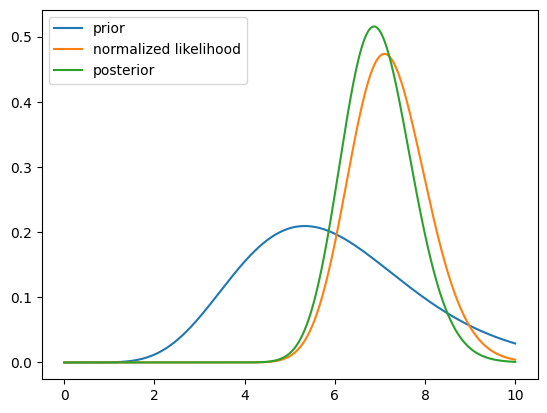

In [14]:
grid = np.linspace(0, 10, 1000)

plt.plot(grid, stats.gamma(s, scale=1 / r).pdf(grid), label="prior")

likelihood = grid**71 * np.exp(-10 * grid)
plt.plot(
    grid, likelihood / np.trapezoid(likelihood, x=grid), label="normalized likelihood"
)

plt.plot(grid, stats.gamma(ss, scale=1 / rr).pdf(grid), label="posterior")
plt.legend()
plt.show()

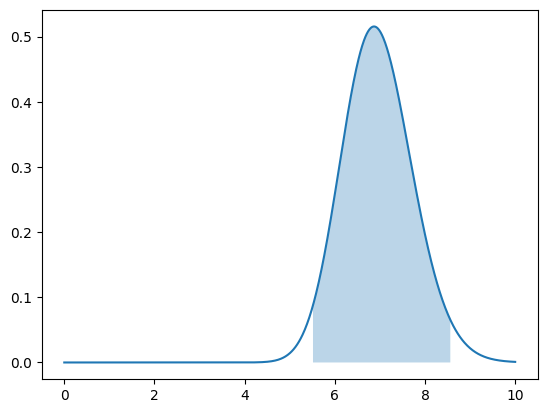

In [15]:
grid = np.linspace(0, 10, 1000)
plt.plot(grid, d.pdf(grid))
grid = np.linspace(*d.ppf([0.025, 0.975]), 1000)
plt.fill_between(grid, 0, d.pdf(grid), alpha=0.3)

In [16]:
y = np.array([0, 1, 2, 3, 4])
n = np.array([109, 65, 22, 3, 1])
r = 0.1
s = 0.1
ss = s + y.dot(n)
rr = r + n.sum()

In [17]:
y.dot(n) / n.sum()  # MLE

np.float64(0.61)

In [18]:
stats.gamma(ss, scale=1 / rr).mean()

np.float64(0.6101949025487257)

### Grid approximation

#### A beta-binomial example

$$
\begin{aligned}
Y\mid \pi &\sim \operatorname{Binomial}(10, \pi)\\
\pi &\sim \operatorname{Beta}(2, 2)
\end{aligned}
$$

Observed: $Y=9$

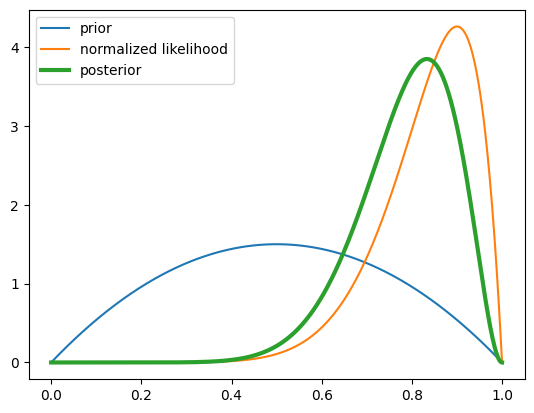

In [19]:
grid = np.linspace(0, 1, 1000)
prior = stats.beta(2, 2).pdf(grid)
plt.plot(grid, prior, label="prior")
likelihood = stats.binom(10, grid).pmf(9)
plt.plot(
    grid, likelihood / np.trapezoid(likelihood, x=grid), label="normalized likelihood"
)
posterior = prior * likelihood / np.trapezoid(prior * likelihood, x=grid)
plt.plot(grid, posterior, label="posterior", lw=3)
plt.legend()
plt.show()

In [20]:
y = np.array([9])
with pm.Model() as model:
    pi = pm.Beta("pi", alpha=2, beta=2)
    likelihood = pm.Binomial("y", n=10, p=pi, observed=y)
    idata = pm.sample(10000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 3 seconds.


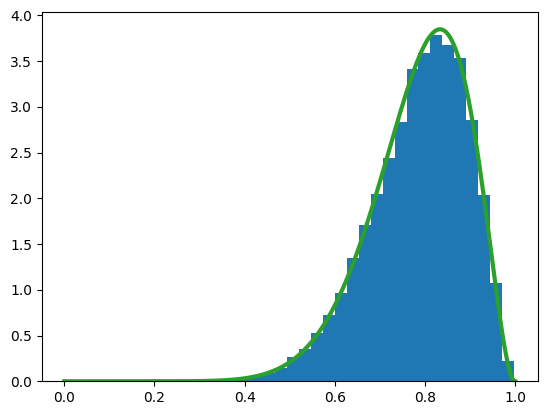

In [21]:
plt.hist(idata.posterior["pi"].to_numpy().ravel(), bins=30, density=True)
plt.plot(grid, posterior, label="posterior", color="C2", lw=3)
plt.show()

#### A gamma-poisson example

$$
\begin{aligned}
Y\mid\lambda &\sim \operatorname{Poisson}(\lambda)\\
\lambda &\sim \operatorname{Gamma}(3, 1)
\end{aligned}
$$

Observed: $(Y_1, Y_2) = (2, 8)$

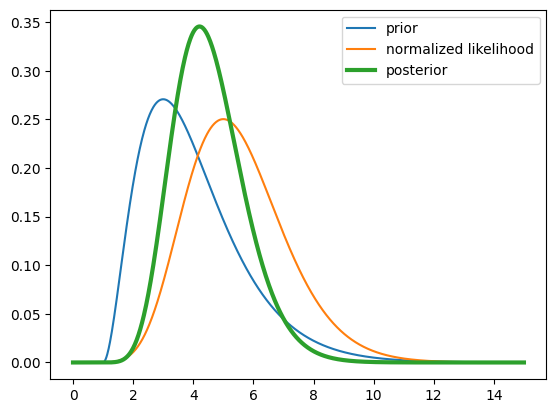

In [22]:
grid = np.linspace(0, 15, 1000)
prior = stats.gamma(3, 1).pdf(grid)
plt.plot(grid, prior, label="prior")
y = np.array([2, 8]).reshape(-1, 1)
likelihood = stats.poisson(grid).pmf(y).prod(axis=0)
plt.plot(
    grid, likelihood / np.trapezoid(likelihood, x=grid), label="normalized likelihood"
)
posterior = prior * likelihood / np.trapezoid(prior * likelihood, x=grid)
plt.plot(grid, posterior, label="posterior", lw=3)
plt.legend()
plt.show()

In [23]:
y = np.array([2, 8])
with pm.Model() as model:
    mu = pm.Gamma("mu", alpha=3, beta=1)
    likelihood = pm.Poisson("y", mu=mu, observed=y)
    idata = pm.sample(10000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 3 seconds.


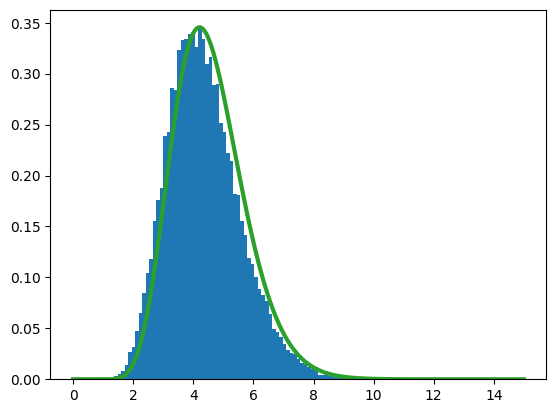

In [24]:
plt.hist(idata.posterior["mu"].to_numpy().ravel(), bins=100, density=True)
plt.plot(grid, posterior, label="posterior", color="C2", lw=3)

$$
\begin{aligned}
Y_i\mid\mu,\sigma &\sim N(\mu, \sigma^2)\\
\mu &\sim N(0, 1)\\
\sigma &\sim \operatorname{Exp}(1)
\end{aligned}
$$

In [25]:
n = 10
rng = np.random.default_rng(3)
mu = stats.norm().rvs(random_state=rng)
sigma = stats.expon().rvs(random_state=rng)
print(mu, sigma)
y = stats.norm(loc=mu, scale=sigma).rvs(size=n, random_state=rng).round(1)

with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=1)
    sigma = pm.Exponential("sigma", lam=1)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...


2.0409191213851825 0.3896568735737038


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [26]:
np.mean(idata.posterior["sigma"].to_numpy().ravel())

np.float64(0.5802860191956004)

$$
f(x\mid\theta) = \binom{n}{x}\theta^x(1 - \theta)^{n - x}
$$

$$
\log f(x\mid\theta) = \log \binom{n}{x} + x\log\theta + (n - x)\log(1 - \theta)
$$

$$
\frac{d}{d\theta}\log f(x\mid\theta) = \frac{x}{\theta} - \frac{n - x}{1 - \theta}
$$

$$
\frac{d}{d\theta}f(x\mid\theta) = 0 \Longleftrightarrow \theta = \frac{x}{n}
$$

$$
\frac{d^2}{d\theta^2} f(x\mid\theta) = -\left(\frac{x}{\theta^2} + \frac{n - x}{(1 - \theta)^2}\right) < 0
$$

Therefore, $\theta = \dfrac{x}{n}$ is a local maximum.

$$
\begin{aligned}
f(x) &= \begin{cases}
0 &\text{if $x < a$,}\\[2ex]
\dfrac{2}{(b-a)(c - a)}(x - a) &\text{if $a\leq x < c$,}\\[3ex]
\dfrac{2}{(b - a)(b - c)}(b - x) &\text{if $c\leq x < b$,}\\[3ex]
0&\text{if $b\leq x$}
\end{cases}
\end{aligned}
$$

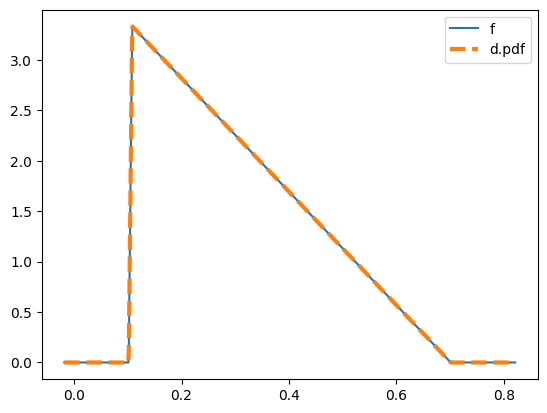

In [40]:
def f(x, a, b, c):
    u = 2 * (x - a) / (b - a) / (c - a)
    v = 2 * (b - x) / (b - a) / (b - c)
    return np.where(a <= x, np.where(x < c, u, np.where(x < b, v, 0)), 0)


rng = np.random.default_rng()
a = rng.uniform()
c = a + rng.uniform()
b = c + rng.uniform()

x = np.linspace(a - 0.2 * (b - a), b + 0.2 * (b - a), 1000)
plt.plot(x, f(x, a, b, c), label="f")

loc = a
scale = b - a
cc = (c - a) / (b - a)

d = stats.triang(cc, loc=loc, scale=scale)
plt.plot(x, d.pdf(x), "--", lw=3, label="d.pdf")

plt.legend()
plt.show()